In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
import sys
import matplotlib.pyplot as plt
!{sys.executable} -m pip list

Package                 Version
----------------------- -----------
alembic                 1.18.4
annotated-types         0.7.0
anyio                   4.13.0
appnope                 0.1.4
asttokens               3.0.1
certifi                 2026.2.25
cloudpickle             3.1.2
colorlog                6.10.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
distro                  1.9.0
executing               2.2.1
fonttools               4.62.1
h11                     0.16.0
httpcore                1.0.9
httpx                   0.28.1
idna                    3.11
imbalanced-learn        0.14.1
importlib_resources     6.5.2
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
Jinja2                  3.1.6
jiter                   0.13.0
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core     

In [2]:
df = pd.read_csv("customer_subscription_churn_usage_patterns.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   str    
 2   plan_type               2800 non-null   str    
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 218.9 KB


In [3]:
df.head(10)

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes
5,6,2024-10-05,Premium,699,13.6,6,0,30,35,Yes
6,7,2023-10-24,Premium,699,14.6,1,0,24,42,Yes
7,8,2024-01-09,Basic,199,21.7,6,2,15,29,Yes
8,9,2023-03-15,Basic,199,9.2,4,5,24,59,Yes
9,10,2024-10-17,Premium,699,13.6,3,1,11,29,No


- между ценой подписки и планом есть зависимость (мультиколлинеарность)
- для удобства удалим колонку планов потому что она не нужна
- но не сейчас
- удаление колонок делается на этапе подготовки данных перед обучением, не в EDA.


In [4]:
df.describe()

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


- по last_login_days_ago мы видим поведенческий сигнал оттока, очень ценый признак

payment_failures: диапазон 0–5, среднее ~2.5.
Предположительно — за фиксированный период.
Точный временной охват не указан в документации датасета.

EDA (Exploratory Data Analysis)

In [5]:
(df['churn'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %'

churn
Yes    57.32 %
No     42.68 %
Name: proportion, dtype: str

/var/folders/d3/y6w48kj55h706cgg4yjss2ch0000gn/T/ipykernel_15598/3806072759.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'churn', palette = 'Set2')


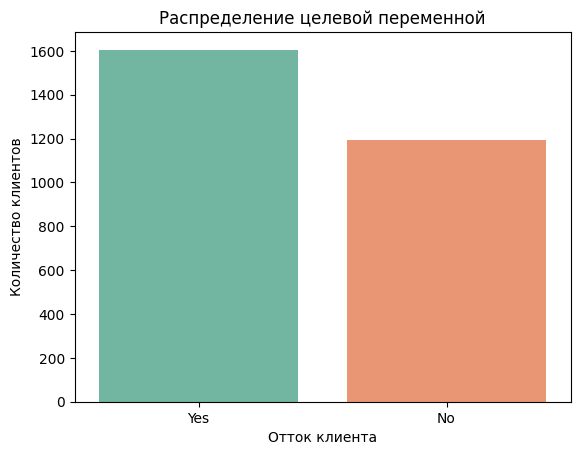

In [6]:
sns.countplot(data = df, x = 'churn', palette = 'Set2')
plt.title('Распределение целевой переменной')
plt.xlabel('Отток клиента')
plt.ylabel('Количество клиентов')
plt.show()

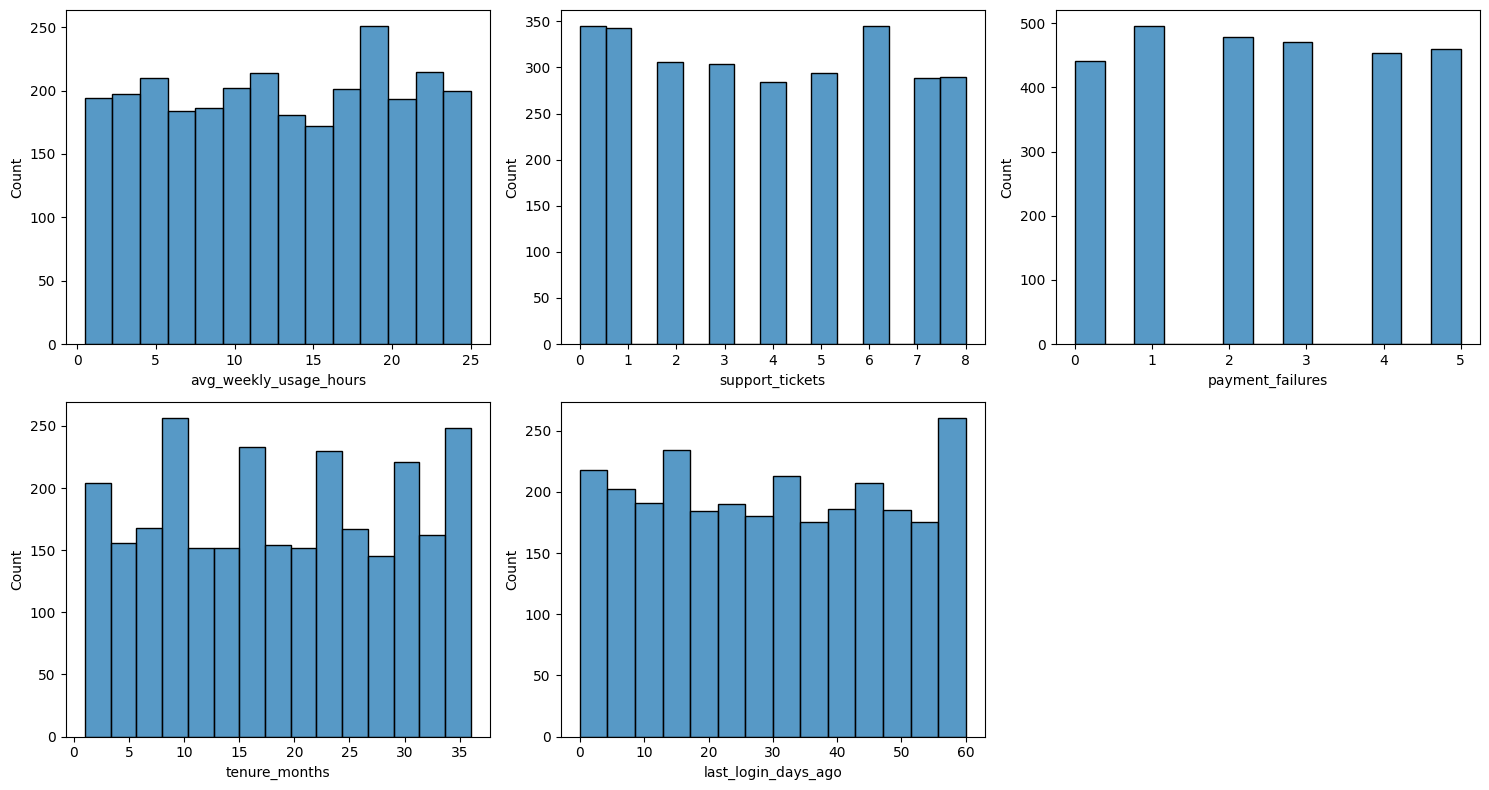

In [7]:
# распределения признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(data=df, x='avg_weekly_usage_hours', ax=axes[0,0])
sns.histplot(data=df, x='support_tickets', ax=axes[0,1])
sns.histplot(data=df, x='payment_failures', ax=axes[0,2])
sns.histplot(data=df, x='tenure_months', ax=axes[1,0])
sns.histplot(data=df, x='last_login_days_ago', ax=axes[1,1])
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

в целом по все признакам у нас наблюдается равномерное распределение

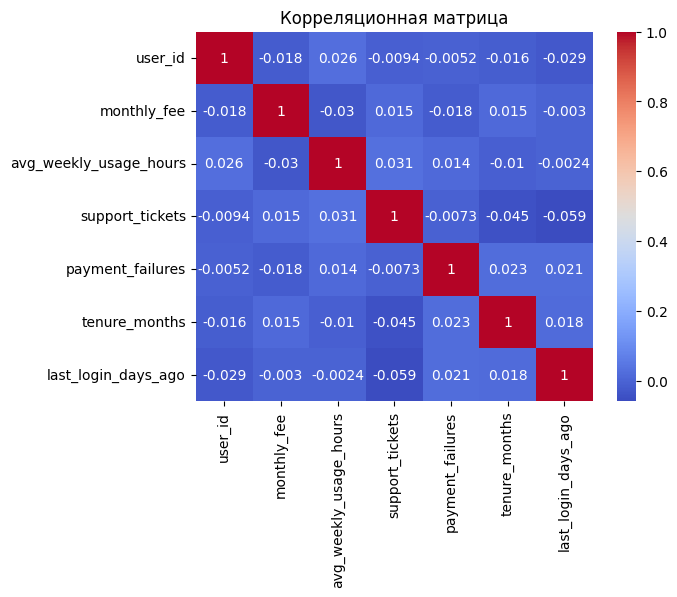

In [8]:
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

- мультиколлинеарность отсутствует (кроме plan_type/monthly_fee)
- признаки независимы друг от друга

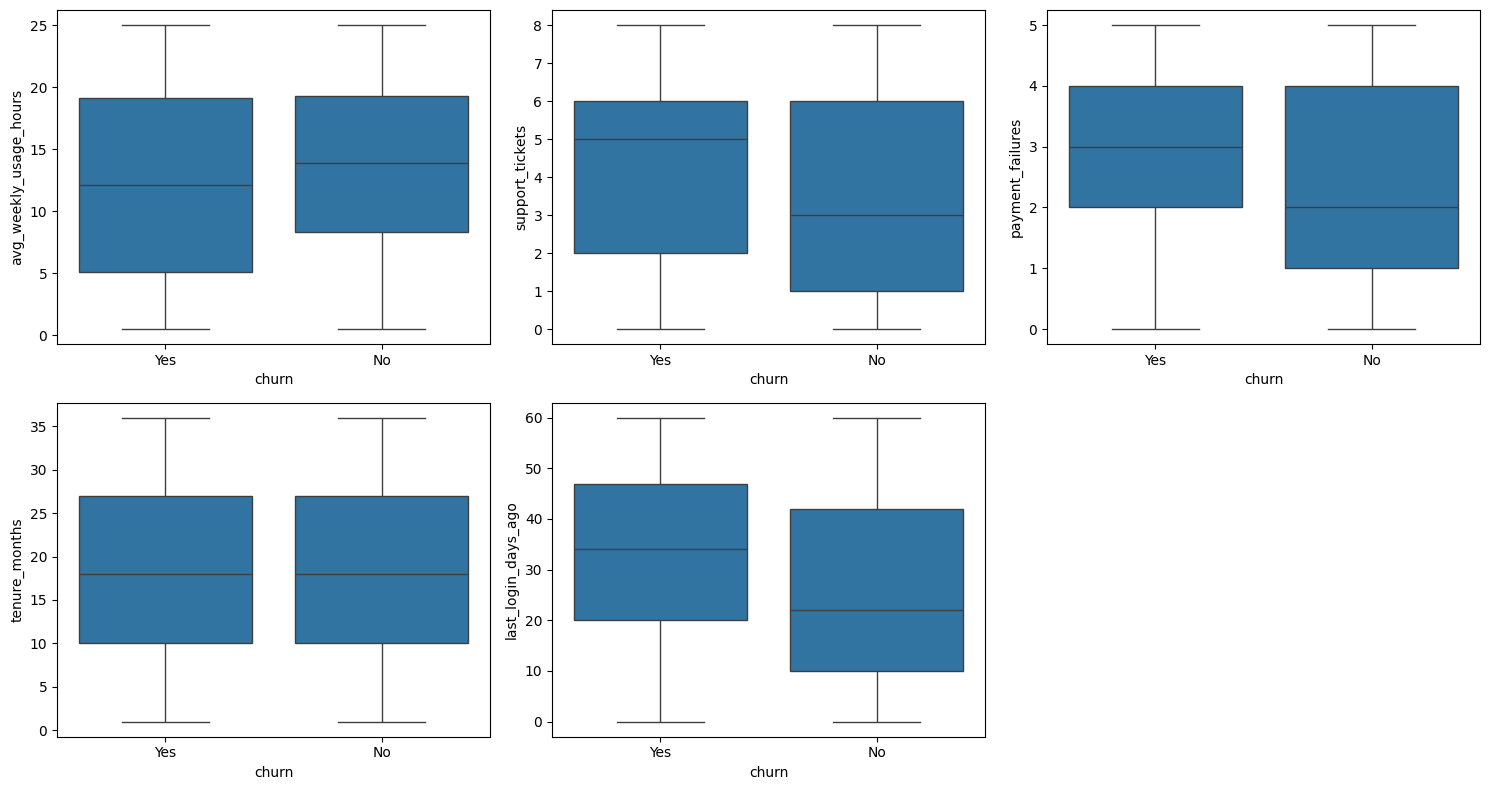

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(data=df, x='churn', y='avg_weekly_usage_hours', ax=axes[0,0])
sns.boxplot(data=df, x='churn', y='support_tickets', ax=axes[0,1])
sns.boxplot(data=df, x='churn', y='payment_failures', ax=axes[0,2])
sns.boxplot(data=df, x='churn', y='tenure_months', ax=axes[1,0])
sns.boxplot(data=df, x='churn', y='last_login_days_ago', ax=axes[1,1])
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

видно что boxplot показывает разницу между целевой переменной и признаком
- те кто логинились давно скорее всего уйдут 
- те кто часто обращаются в поддержку тоже 
- у кого проблема с платежами

ример last_login_days_ago для Yes — большой ящик, значит среди ушедших клиентов разброс по дням последнего входа очень широкий.
признаки которые связаны максимально с оттоком

По предобработке нужно сделать:

Удалить лишние колонки — user_id и plan_type
Преобразовать signup_date — сейчас это строка, нужно извлечь что-то полезное (например количество дней с момента регистрации)
Закодировать churn — заменить Yes/No на 1/0
Нормализация — привести числовые признаки к одному масштабу (нужно для некоторых алгоритмов)